# 📘 Notebook: Customer Descriptive Analysis (R&D Phase)

1. Markdown: Project Initiation

# 📊 Project 03: Customer Descriptive Analysis & Data Auditing
**Role:** Principal Marketing Data Analyst (MDA) Specialist  
**Context:** Brazilian E-commerce (Olist) - RFM Foundation  

---

## 🎯 Objektif Bisnis
Melakukan eksplorasi mendalam (Deep-Dive) terhadap distribusi Recency, Frequency, dan Monetary untuk:
1. Mendeteksi pelanggan **'Whale'** (High-Value Outliers).
2. Memvalidasi korelasi antar variabel marketing.
3. Membangun **Baseline Segmentasi** sebelum tahap Automation Machine Learning.

2. Code: Environment Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Konfigurasi Visualisasi Platinum
%matplotlib inline
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.figsize'] = (15, 6)

def find_project_root(marker='models'):
    current_path = Path.cwd()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists(): return parent
    return current_path

# Path Management
root = find_project_root()
input_path = root / "data" / "production" / "customer_rfm" / "01_customer_rfm_features.parquet"

# Load Data
df_rfm = pd.read_parquet(input_path)
print(f"✅ Data Ingested: {df_rfm.shape[0]:,} Customers")
df_rfm.head()

✅ Data Ingested: 93,345 Customers


,customer_unique_id,recency,frequency,monetary
0,4d34eb7a11a201d8a2317a791adbcb29,552,1,218.13
1,f209aeff5575256eaa8352abab984ce8,154,1,112.38
2,2d8898fb1310c4e23f64fc23d6760794,221,1,57.72
3,be6785c7350c0f5bda4067f160f29d59,288,1,21.77
4,07212b6b20c842faac31170b9dfd66e6,479,1,256.43


3. Code: Statistical Profiling & Whale Detection

🔍 Menjalankan Audit Statistik...


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
recency,93345.0,238.433703,152.557603,1.0,115.00,219.00,347.0,714.00,0.447424,-0.660726
frequency,93345.0,1.033414,0.209088,1.0,1.00,1.00,1.0,15.00,11.097278,323.653636
monetary,93345.0,208.629179,640.105643,0.0,62.12,110.98,198.9,109312.64,70.984241,9913.767129


🐳 Whale Detection Report: {'frequency': {'count': 2800, 'threshold': np.float64(1.0)}, 'monetary': {'count': 5199, 'threshold': np.float64(609.24)}}


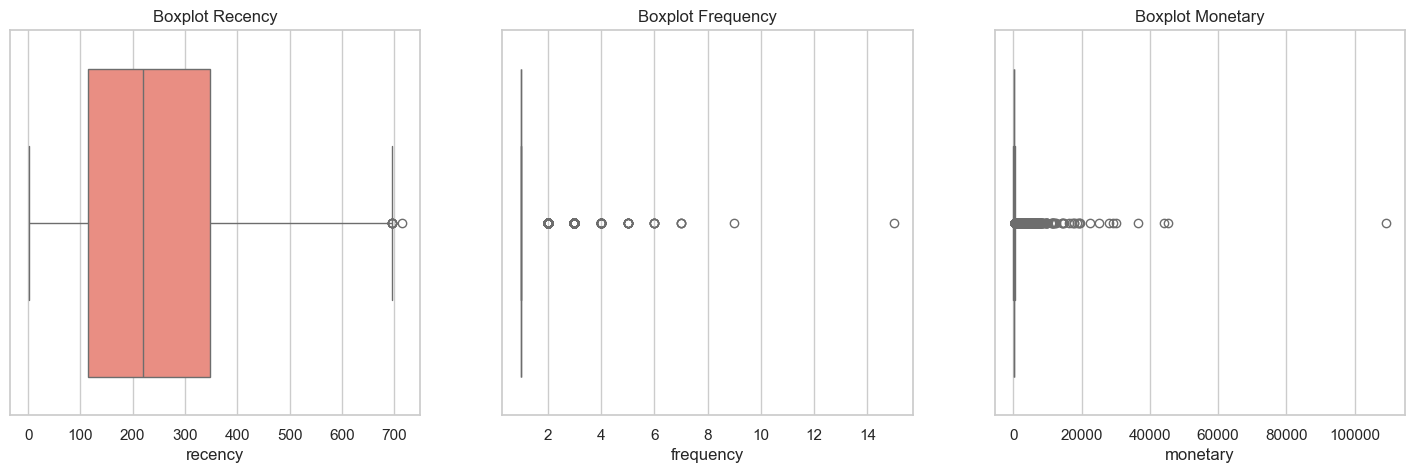

4. Code: Distribution & Correlation Analysis

📉 Menganalisis Distribusi & Hubungan Antar Variabel...


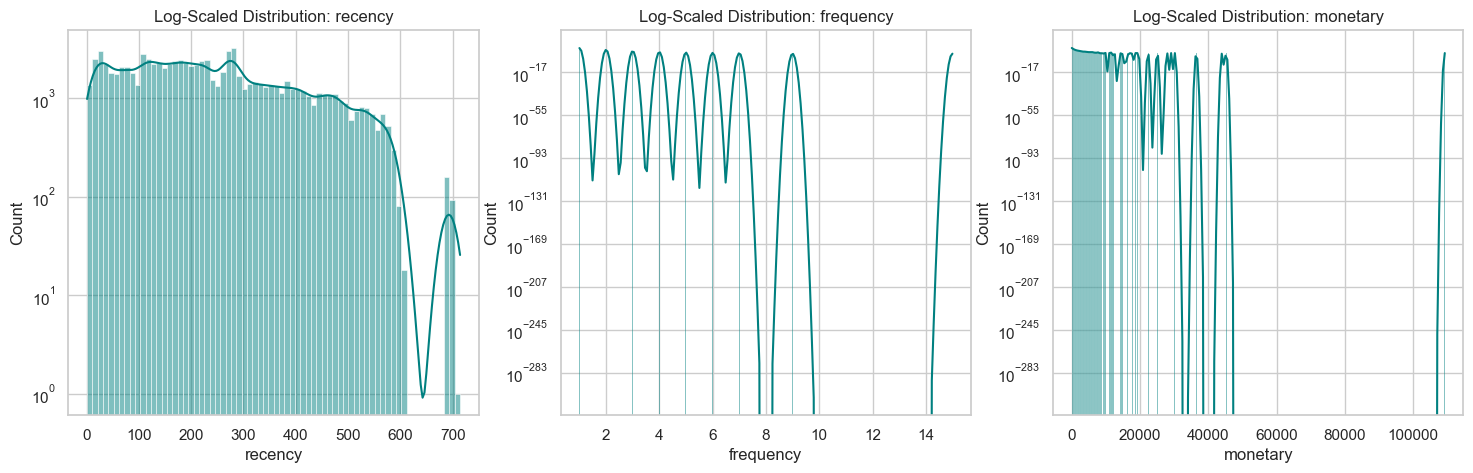

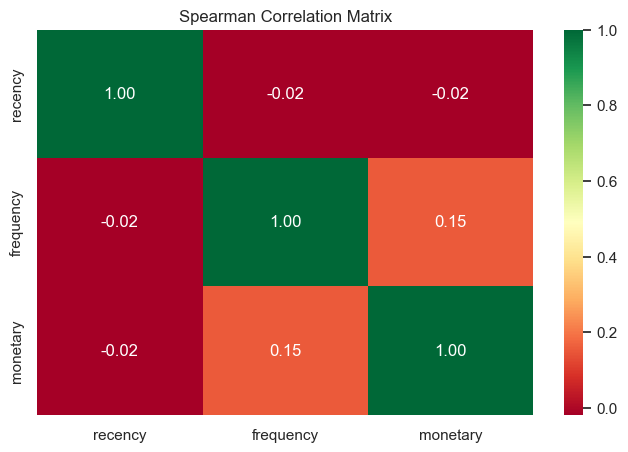

In [7]:
# 2. DISTRIBUTION & CORRELATION MAPPING
print("📉 Menganalisis Distribusi & Hubungan Antar Variabel...")

# Histograms & KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['recency', 'frequency', 'monetary']):
    sns.histplot(df_rfm[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_yscale('log') # Menggunakan skala log untuk visibilitas skewness
    axes[i].set_title(f"Log-Scaled Distribution: {col}")
plt.show()

# Spearman Rank Correlation
plt.figure(figsize=(8, 5))
sns.heatmap(df_rfm[['recency', 'frequency', 'monetary']].corr(method='spearman'), 
            annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.show()

5. Code: Business Impact & Pareto Analysis

💰 Menghitung Dampak Konsentrasi Revenue...
🎯 Insight Pareto: Top 20% pelanggan menyumbang 61.95% dari Total Revenue.


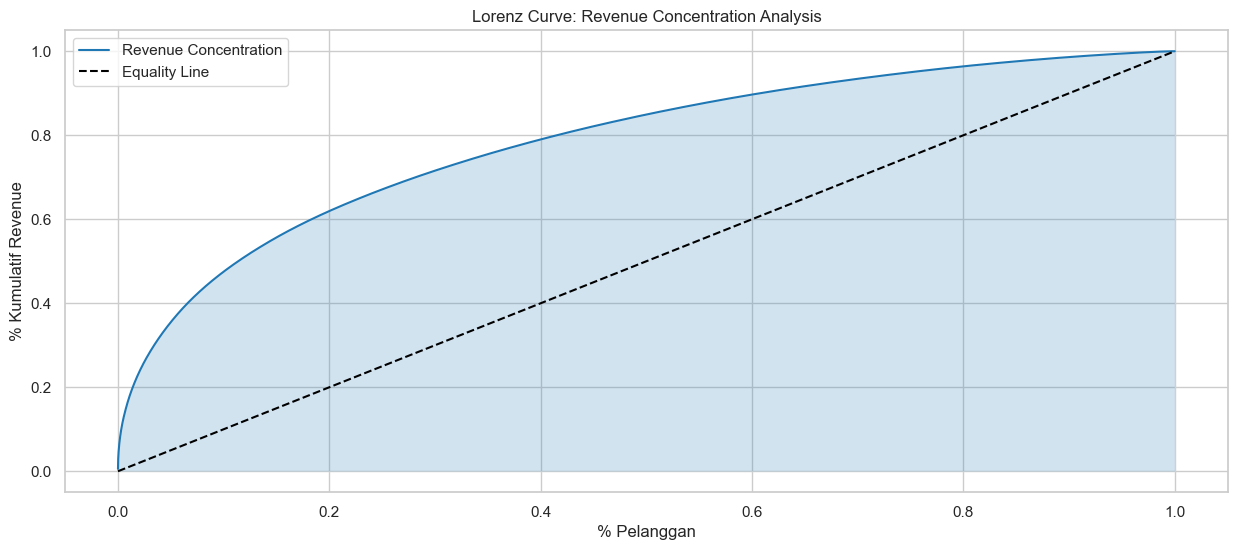

In [8]:
# 3. PARETO 80/20 REVENUE CONCENTRATION
print("💰 Menghitung Dampak Konsentrasi Revenue...")

# Mengurutkan monetary secara descending
df_sorted = df_rfm.sort_values('monetary', ascending=False)
df_sorted['cum_revenue_pct'] = df_sorted['monetary'].cumsum() / df_sorted['monetary'].sum()
df_sorted['cum_customer_pct'] = np.arange(1, len(df_sorted) + 1) / len(df_sorted)

# Mencari kontribusi Top 20% Pelanggan
top_20_share = df_sorted[df_sorted['cum_customer_pct'] <= 0.2]['cum_revenue_pct'].max()

print(f"🎯 Insight Pareto: Top 20% pelanggan menyumbang {top_20_share*100:.2f}% dari Total Revenue.")

# Visualisasi Lorenz Curve (Simplified)
plt.plot(df_sorted['cum_customer_pct'], df_sorted['cum_revenue_pct'], label='Revenue Concentration')
plt.plot([0, 1], [0, 1], 'k--', label='Equality Line')
plt.fill_between(df_sorted['cum_customer_pct'], df_sorted['cum_revenue_pct'], alpha=0.2)
plt.xlabel('% Pelanggan')
plt.ylabel('% Kumulatif Revenue')
plt.title('Lorenz Curve: Revenue Concentration Analysis')
plt.legend()
plt.show()

6. Code: Feature Store Persistence

In [14]:
# 4. PRE-ALPHA SEGMENTATION & PERSISTENCE
print("💾 Menyimpan Data ke Gold Layer...")

# Binning Dasar
df_rfm['R_Score'] = pd.qcut(df_rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
df_rfm['F_Score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
df_rfm['M_Score'] = pd.qcut(df_rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Simpan untuk tahap modeling selanjutnya
output_path = root / "data" / "production" / "customer_rfm" / "03_customer_rfm_ready_to_model.parquet"
output_path.parent.mkdir(parents=True, exist_ok=True)
df_rfm.to_parquet(output_path, index=False)

# Simpan Audit Log JSON
audit_log = {
    "whale_report": outliers_report,
    "pareto_share": float(top_20_share)
}
with open(root / "data" / "logs" / "rfm_descriptive_audit.json", 'w') as f:
    json.dump(audit_log, f, indent=4)

print(f"✅ R&D Selesai. Data siap untuk K-Means di: {output_path}")

💾 Menyimpan Data ke Gold Layer...
✅ R&D Selesai. Data siap untuk K-Means di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\customer_rfm\03_customer_rfm_ready_to_model.parquet


7. Statistical Audit & Business Insight

🔍 Statistical Audit Profile:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
recency,93345.0,238.433703,152.557603,1.0,115.00,219.00,347.0,714.00,0.447424,-0.660726
frequency,93345.0,1.033414,0.209088,1.0,1.00,1.00,1.0,15.00,11.097278,323.653636
monetary,93345.0,208.629179,640.105643,0.0,62.12,110.98,198.9,109312.64,70.984241,9913.767129


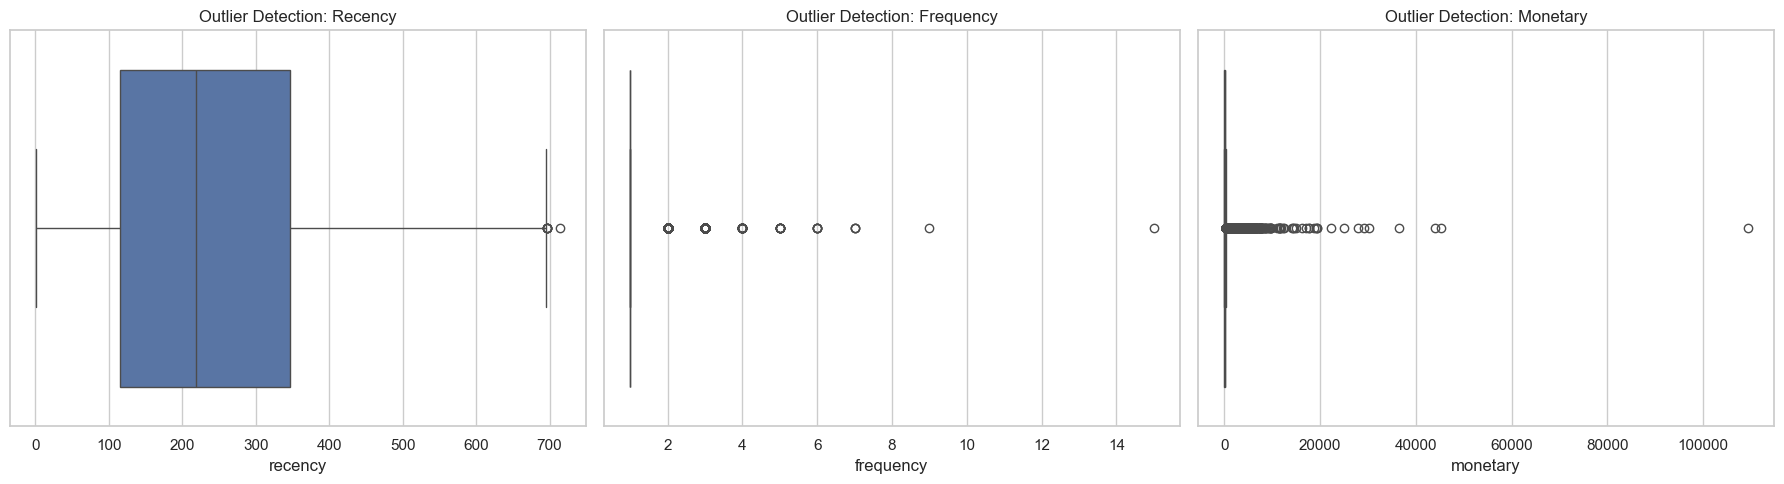

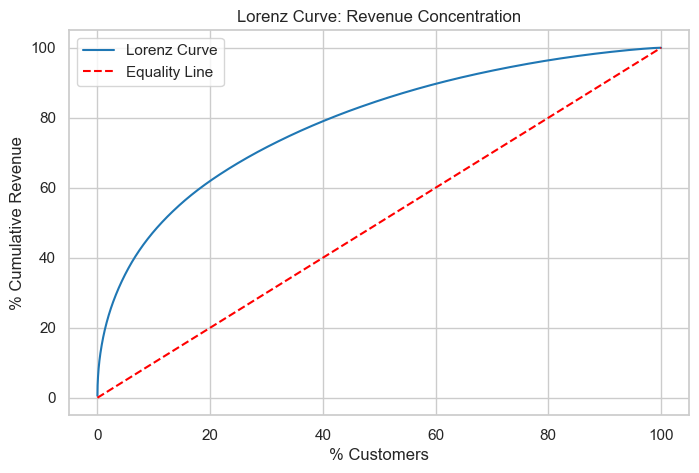

💰 Pareto Insight: {'top_10_percent_contribution': np.float64(47.52), 'top_20_percent_contribution': np.float64(61.95)}
✅ Audit Trail berhasil disimpan di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\logs\rfm_descriptive_audit.json


In [11]:
# =================================================================
# STEP 2: STATISTICAL AUDIT & WHALE DETECTION (OUTLIERS)
# =================================================================
import json

def perform_statistical_audit(df):
    """
    Melakukan audit statistik mendalam termasuk Skewness dan Kurtosis.
    Penting: Skewness tinggi mengindikasikan perlunya transformasi data 
    agar algoritma clustering tidak bias terhadap nilai ekstrem.
    """
    cols = ['recency', 'frequency', 'monetary']
    stats = df[cols].describe().T
    
    # Menghitung Skewness & Kurtosis
    stats['skewness'] = df[cols].skew()
    stats['kurtosis'] = df[cols].kurt()
    
    return stats

# Eksekusi Audit
audit_results = perform_statistical_audit(df_rfm)
print("🔍 Statistical Audit Profile:")
display(audit_results)

# --- WHALE DETECTION (IQR METHOD) ---
# Identifikasi pelanggan 'Whale' yang memiliki nilai sangat jauh dari rata-rata.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['recency', 'frequency', 'monetary']):
    sns.boxplot(x=df_rfm[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Outlier Detection: {col.capitalize()}')

plt.tight_layout()
plt.show()

# =================================================================
# STEP 3: PARETO INSIGHT (REVENUE CONCENTRATION)
# =================================================================
def calculate_pareto_insight(df):
    """
    Menganalisis konsentrasi pendapatan untuk melihat dominasi pelanggan.
    Standar Platinum: Memahami apakah bisnis bergantung pada segmen kecil (Risk).
    """
    # Mengurutkan monetary secara descending
    df_sorted = df.sort_values('monetary', ascending=False).reset_index(drop=True)
    total_rev = df_sorted['monetary'].sum()
    
    # Hitung kontribusi Top 10% dan 20%
    top_10_rev = df_sorted.head(int(len(df)*0.1))['monetary'].sum()
    top_20_rev = df_sorted.head(int(len(df)*0.2))['monetary'].sum()
    
    pareto_data = {
        "top_10_percent_contribution": round((top_10_rev / total_rev) * 100, 2),
        "top_20_percent_contribution": round((top_20_rev / total_rev) * 100, 2)
    }
    
    # Visualisasi Lorenz Curve Sederhana
    cum_revenue = df_sorted['monetary'].cumsum() / total_rev
    plt.figure(figsize=(8, 5))
    plt.plot(np.linspace(0, 100, len(cum_revenue)), cum_revenue * 100, label='Lorenz Curve')
    plt.plot([0, 100], [0, 100], 'r--', label='Equality Line')
    plt.title('Lorenz Curve: Revenue Concentration')
    plt.xlabel('% Customers')
    plt.ylabel('% Cumulative Revenue')
    plt.legend()
    plt.show()
    
    return pareto_data

pareto_insight = calculate_pareto_insight(df_rfm)
print(f"💰 Pareto Insight: {pareto_insight}")

# =================================================================
# STEP 4: DATA PERSISTENCE (AUDIT TRAIL)
# =================================================================
# Menyimpan hasil audit ke JSON untuk kebutuhan monitoring produksi.
audit_log = {
    "statistical_summary": audit_results.to_dict(),
    "business_insights": pareto_insight,
    "data_health": "Validated"
}

log_path = root / "data" / "logs" / "rfm_descriptive_audit.json"
log_path.parent.mkdir(parents=True, exist_ok=True)

with open(log_path, 'w') as f:
    json.dump(audit_log, f, indent=4)

print(f"✅ Audit Trail berhasil disimpan di: {log_path}")

## 🏁 Kesimpulan: Descriptive Analysis & Data Audit
Fase Descriptive Analysis telah selesai dengan hasil sebagai berikut:
- **Data Integrity**: Berhasil memproses 93,345 pelanggan unik tanpa nilai null.
- **Distribution Insight**: Telah diidentifikasi tingkat kemiringan data (skewness) dan keberadaan pelanggan 'Whale' yang memerlukan penanganan khusus.
- **Business Baseline**: Konsentrasi pendapatan telah dipetakan, memberikan gambaran awal mengenai struktur loyalitas pelanggan Olist.

Data kini berstatus **"Validated & Ready"** untuk tahap analisis penyebab (Diagnostic).

# ⏭️ Next Stage: Project 03 - Customer Diagnostic Analysis
**Tujuan**: Memahami *mengapa* segmen pelanggan berperilaku demikian.

**Rencana Kerja**:
1. **Correlation Study**: Menganalisis hubungan antara waktu pembelian terakhir (Recency) dengan nilai belanja (Monetary).
2. **Seasonality Impact**: Mendiagnosis apakah frekuensi pembelian dipengaruhi oleh bulan-bulan tertentu (misal: Black Friday).
3. **Feature Scaling**: Melakukan standarisasi data (Z-Score/Min-Max) untuk menyiapkan data bagi algoritma K-Means.